# HackBots - Tech-Triathlon 2026 Datathon - Final Notebook

**Task 1: predict service time and lateness** for every planned delivery in the test set.

| Output | Meaning |
|---|---|
| `pred_service_min` | predicted handling time at the outlet (minutes) |
| `pred_late_prob` | probability the vehicle arrives after the outlet's delivery window closes |

**Contents**
1. Configuration and data loading
2. Data audit (key checks)
3. **Label construction** - neither target exists in the data; both are derived from route-leg actuals
4. Preprocessing and feature engineering - planning-time features + a realistic **route simulation**
5. Validation design - forward-in-time folds rebuilt exactly like the test
6. Model - stacked, route-aware HistGradientBoosting pipeline (scikit-learn only)
7. Cross-validation, evaluation (all metrics) and post-hoc calibration
8. Final training on all data and saving the models
9. Test predictions and `submission_task1.csv`
10. **Inference demo**: load the saved models, print inputs and predictions

Rules respected: no pretrained models, no proprietary APIs, no AutoML - every model is a scikit-learn `HistGradientBoosting` estimator trained here.
Task 2A is appended in a later section of this notebook.

## 1. Configuration and data loading
`RUN_CV` runs the 3-fold validation (~6 min) - it produces every evaluation number and the calibration.
`RETRAIN` refits the final model on all training data (~3 min); with `RETRAIN = False` the saved model in `models/` is used.

The data folder is detected automatically: either the competition layout (`Training Data/`, `Test Data/`, `General Data/`, `Submission Templates/`)
next to / above this notebook, or the team repository layout (`../data/raw/train|test|reference|templates`).

In [1]:
RUN_CV = True        # 3-fold forward validation + calibration (~6 min)
RETRAIN = True       # refit the final model on all training data (~3 min); False = load models/task1_models.joblib

import json, time, warnings
from pathlib import Path
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from sklearn import metrics as skm
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (log_loss, brier_score_loss, roc_auc_score, mean_absolute_error, mean_squared_error, r2_score)
warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 170)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'raw').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIRS = {k: PROJECT_ROOT / 'data' / 'raw' / k for k in ['train', 'test', 'reference', 'templates']}
MODEL_DIR = PROJECT_ROOT / 'HackBots_Datathon_Submision' / 'models'
PRED_DIR = PROJECT_ROOT / 'HackBots_Datathon_Submision' / 'predictions'
MODEL_DIR.mkdir(exist_ok=True); PRED_DIR.mkdir(exist_ok=True)
SEED = 42
print({k: str(v) for k, v in DATA_DIRS.items()})

{'train': '..\\data\\raw\\train', 'test': '..\\data\\raw\\test', 'reference': '..\\data\\raw\\reference', 'templates': '..\\data\\raw\\templates'}


### Shared helpers
Time parsing, label definition, the order-to-leg join and the submission contract check.

In [2]:
TASK1_COLS = ["delivery_id", "pred_service_min", "pred_late_prob"]


def hhmm_to_min(s: pd.Series) -> pd.Series:
    """'HH:MM' -> minutes since midnight (NaN stays NaN). Clock times only, no date."""
    parts = s.astype("string").str.split(":", expand=True)
    return pd.to_numeric(parts[0]) * 60 + pd.to_numeric(parts[1])


def make_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Task 1 labels from a joined train table that has the *_m minute columns.

    service_min = leave_outlet - max(arrival, window_open)   (early vehicles wait; the wait is not handling)
    late        = arrival > window_close                      (strictly after the window closes)
    wait_min    = max(window_open - arrival, 0)               (kept for diagnostics only)
    """
    arrival, opens = df["arrival_time_m"], df["window_open_time_m"]
    return pd.DataFrame({
        "service_min": df["leave_outlet_time_m"] - np.maximum(arrival, opens),
        "late": (arrival > df["window_close_time_m"]).astype(int),
        "wait_min": (opens - arrival).clip(lower=0),
    }, index=df.index)


def join_orders_to_legs(orders: pd.DataFrame, legs: pd.DataFrame) -> pd.DataFrame:
    """Join dispatched orders to their route leg on (route_id, seq_in_route == seq).

    Order columns win on name clashes; leg-only columns get suffix '_leg'.
    """
    dispatched = orders.dropna(subset=["route_id"])
    return dispatched.merge(
        legs, left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"],
        how="left", suffixes=("", "_leg"), validate="one_to_one",
    )


def validate_submission(sub: pd.DataFrame, template: pd.DataFrame) -> None:
    """Raise AssertionError if the Task 1 submission breaks the template contract."""
    assert list(sub.columns) == TASK1_COLS, f"columns must be {TASK1_COLS}"
    assert len(sub) == len(template), f"row count {len(sub)} != {len(template)}"
    assert (sub["delivery_id"].values == template["delivery_id"].values).all(), \
        "delivery_id values/order differ from the template"
    assert sub[TASK1_COLS[1:]].notna().all().all(), "NaN in prediction columns"
    assert np.isfinite(sub[TASK1_COLS[1:]].to_numpy(dtype=float)).all(), "non-finite values"
    assert (sub["pred_service_min"] > 0).all(), "pred_service_min must be positive"
    assert sub["pred_late_prob"].between(0, 1).all(), "pred_late_prob must be in [0, 1]"

In [3]:
def load_raw(name, subdir):
    return pd.read_csv(DATA_DIRS[subdir] / name)

t = {
    'deliveries_train': load_raw('deliveries_train.csv', 'train'), 'legs_train': load_raw('route_legs_train.csv', 'train'),
    'orders_test': load_raw('task1_test_inputs.csv', 'test'), 'legs_test': load_raw('route_legs_test.csv', 'test'),
    'outlets': load_raw('outlets.csv', 'reference'), 'calendar': load_raw('calendar.csv', 'reference'),
    'service_allowance': load_raw('service_allowance.csv', 'reference'), 'traffic': load_raw('traffic_speed.csv', 'reference'),
    'roads': load_raw('road_conditions.csv', 'reference'), 'vehicles': load_raw('vehicles.csv', 'reference'),
    'district_travel': load_raw('district_travel.csv', 'reference'), 'template': load_raw('submission_task1.csv', 'templates'),
}
pd.DataFrame({k: v.shape for k, v in t.items()}, index=['rows', 'cols']).T

,rows,cols
deliveries_train,92307,20
legs_train,91894,22
orders_test,5014,20
legs_test,5014,18
outlets,120,9
calendar,910,12
service_allowance,9,3
traffic,576,4
roads,10920,3
vehicles,60,9


## 2. Data audit - key checks
Full audit: `notebooks/task1/01_data_audit.ipynb`. Findings that drive later decisions:

| Finding | Decision |
|---|---|
| 413 `not_run` orders have no route / vehicle / times | excluded from Task 1 training (no label possible) |
| Orders join one-to-one to route legs on (`route_id`, `seq_in_route`) | no repair needed |
| No midnight wrap; `arrival = depart + travel` within +-1 min | clock times usable as minutes |
| Test (2026-02-16..03-28) is after all training data, 66% monsoon legs | forward-in-time validation |

In [4]:
TIME_COLS = ['planned_depart_time', 'planned_arrival_time', 'actual_depart_time', 'arrival_time',
             'leave_outlet_time', 'window_open_time', 'window_close_time']
def add_minutes(df):
    df = df.copy()
    for c in TIME_COLS:
        if c in df: df[c + '_m'] = hhmm_to_min(df[c])
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values(['route_id', 'seq']).reset_index(drop=True)

tr = add_minutes(join_orders_to_legs(t['deliveries_train'], t['legs_train']))
te = add_minutes(join_orders_to_legs(t['orders_test'], t['legs_test']))
d = t['deliveries_train']
print('train orders by status:', d.dispatch_status.value_counts().to_dict(), '-> dispatched & joined:', len(tr))
print('test orders joined:', len(te), '| legs unmatched (train/test):', len(t['legs_train']) - len(tr), len(t['legs_test']) - len(te))
print('fields agree order vs leg:', all((tr[a] == tr[b]).all() for a, b in [('brand', 'brand_leg'), ('district', 'district_leg'), ('vehicle_id', 'vehicle_id_leg'), ('outlet_id', 'to_outlet')]))
print('midnight wraps:', int((tr.leave_outlet_time_m < tr.arrival_time_m).sum() + (tr.arrival_time_m < tr.actual_depart_time_m).sum()))
gap = tr.arrival_time_m - tr.actual_depart_time_m - tr.actual_travel_duration_min
print('arrival - (depart + travel) values:', gap.value_counts().to_dict(), '(rounding only)')
print('train', tr.date.min().date(), '->', tr.date.max().date(), '| test', te.date.min().date(), '->', te.date.max().date(), '| test monsoon share', round(te.monsoon.mean(), 3))

train orders by status: {'attempted': 90351, 'deferred': 1543, 'not_run': 413} -> dispatched & joined: 91894
test orders joined: 5014 | legs unmatched (train/test): 0 0
fields agree order vs leg: True
midnight wraps: 0
arrival - (depart + travel) values: {np.int64(0): 68820, np.int64(1): 11556, np.int64(-1): 11518} (rounding only)
train 2024-01-01 -> 2026-02-14 | test 2026-02-16 -> 2026-03-28 | test monsoon share 0.665


## 3. Label construction
Neither target is supplied. Both are derived from the training route legs:

| Target | Definition | Why |
|---|---|---|
| `service_min` | `leave_outlet_time - max(arrival_time, window_open_time)` | Outlets receive goods only inside their window. A vehicle that arrives early **waits** until it opens; that wait is not handling time. |
| `late` | `arrival_time > window_close_time` | Lateness = arrival *after the window closes* (booklet). Arriving early or inside the window is on time. |

The evidence below shows why the wait must be removed: for early arrivals the raw stay (`leave - arrival`) is mostly the wait.

In [5]:
tr = tr.join(make_labels(tr))
tr['stay_min'] = tr.leave_outlet_time_m - tr.arrival_time_m
early = tr[tr.wait_min > 0]
print(f'early arrivals: {len(early)} ({len(early)/len(tr):.1%}), mean wait {early.wait_min.mean():.1f} min')
print(f'corr(raw stay, wait) for early arrivals : {early.stay_min.corr(early.wait_min):.3f}   <- naive label is mostly the wait')
print(f'corr(service_min, wait) for early arrivals: {early.service_min.corr(early.wait_min):.3f}  <- corrected label is independent of it')
print(f'naive label would overstate {(tr.stay_min > tr.service_min).mean():.1%} of rows by {(tr.stay_min - tr.service_min)[tr.stay_min > tr.service_min].mean():.1f} min on average')
print('\nservice_min: non-positive', int((tr.service_min <= 0).sum()), '| range', tr.service_min.min(), '-', tr.service_min.max())
print(tr.groupby('brand').agg(service_mean=('service_min', 'mean'), service_median=('service_min', 'median'), late_rate=('late', 'mean'), n=('late', 'size')).round(3))
print('\nlate boundary: rate with > :', round(tr.late.mean(), 4), '| with >= :', round((tr.arrival_time_m >= tr.window_close_time_m).mean(), 4), '(choice not material)')
slack = tr.window_close_time_m - tr.planned_arrival_time_m
print('late rate by planned slack (min):'); print(tr.late.groupby(pd.cut(slack, [-999, 0, 15, 30, 60, 90, 120, 180, 999])).mean().round(3).to_string())

early arrivals: 4023 (4.4%), mean wait 20.0 min
corr(raw stay, wait) for early arrivals : 0.810   <- naive label is mostly the wait
corr(service_min, wait) for early arrivals: -0.107  <- corrected label is independent of it
naive label would overstate 4.4% of rows by 20.0 min on average

service_min: non-positive 0 | range 2 - 428
       service_mean  service_median  late_rate      n
brand                                                
Fresh        17.144            15.0      0.204  87457
Style        52.557            46.0      0.055   2733
Tech         60.585            52.0      0.025   1704

late boundary: rate with > : 0.1958 | with >= : 0.1988 (choice not material)
late rate by planned slack (min):
(-999, 0]     0.983
(0, 15]       0.923
(15, 30]      0.794
(30, 60]      0.528
(60, 90]      0.252
(90, 120]     0.105
(120, 180]    0.046
(180, 999]    0.015


**Leakage rule.** A column may be a model input only if it also exists in the test table. Actual times (`actual_*`, `arrival_time`, `leave_outlet_time`)
exist only in training; they are kept in a separate table and enter the features **only as past aggregates** (history known before the day being predicted).

In [6]:
test_cols = set(te.columns)
safe_cols = [c for c in tr.columns if c in test_cols]
LABEL_COLS = ['service_min', 'late']
actual_cols = ['actual_depart_time', 'actual_travel_duration_min', 'arrival_time', 'leave_outlet_time',
               'actual_depart_time_m', 'arrival_time_m', 'leave_outlet_time_m', 'wait_min', 'stay_min']
train_lab = tr[safe_cols + LABEL_COLS].copy()
actuals = tr[['delivery_id'] + actual_cols].copy()
test_base = te.copy()
assert not set(actual_cols) & set(test_base.columns)
print('train_lab', train_lab.shape, '| actuals', actuals.shape, '| test_base', test_base.shape)

train_lab (91894, 43) | actuals (91894, 10) | test_base (5014, 41)


## 4. Preprocessing and feature engineering
All features are computable **before the vehicle leaves**.

Two facts found in the data drive the design:
1. The dispatcher's plan uses **exactly** the service allowance as dwell time at each stop and assumes clear roads.
2. Actual travel ~= `planned travel x (100 / speed_index) x (100 / disruption_index)` (log correlation 0.98).

So the plan is optimistic in a *predictable* way, and each route can be **re-simulated realistically**: expected travel from traffic and road
conditions, outlet-specific handling time from history, waiting for the window to open, and the vehicle's typical departure delay.
Simulated slack predicts lateness far better than the planned slack (AUC 0.954 vs 0.859).

| Family | Examples |
|---|---|
| Order | log weight / volume / units, density, kg per unit, deferred flag |
| Outlet | dock type, parking constraint, mall, window open / close / width |
| Vehicle | capacity, load factor, fuel profile |
| Leg + route | planned slack, stop position, stops remaining, cumulative planned travel, weight still on board |
| Context | payday distance, festival ramp, monsoon, traffic speed index at the planned hour, road disruption |
| History (past-only) | smoothed outlet / vehicle / district service ratio, late rate, travel-speed residual, departure delay |
| Route simulation | expected arrival, slack, wait - with plan allowances and with personalised history |

History is **lagged 21 days** for training rows (test rows are 2-42 days after the end of training), smoothed toward fixed priors so no
full-data statistic leaks in. Time proxies (history counts, ISO week) are excluded.

In [7]:
CATEGORICAL = ["brand", "district", "depot", "temp_requirement", "vehicle_type", "vehicle_temp",
               "dock_type", "parking_constraint", "road_class", "fuel_type", "outlet_id", "vehicle_id"]
LABELS = ["service_min", "late"]

# smoothing strength (pseudo-observations) for history means
M_SMOOTH = 20
# train rows only see history at least this old, mimicking test (2-42 days after train ends, mean ~21)
HIST_GAP_DAYS = 21


# ---- reference joins: outlets, vehicles, district travel, calendar, road conditions, service allowance
def _join_reference(df: pd.DataFrame, t: dict) -> pd.DataFrame:
    o = t["outlets"][["outlet_id", "dock_type", "parking_constraint", "mall_window"]]
    v = t["vehicles"].rename(columns={"type": "veh_type_ref", "temp": "veh_temp_ref", "depot": "veh_depot"})
    v = v[["vehicle_id", "weight_cap_kg", "volume_cap_m3", "fuel_type", "km_per_l", "weekly_fuel_quota_l"]]
    dt = t["district_travel"][["district", "road_class", "free_flow_kmh", "depot_to_district_km",
                               "depot_to_district_freeflow_min", "inter_stop_km", "inter_stop_freeflow_min"]]
    cal = t["calendar"].assign(date=lambda d: pd.to_datetime(d.date))
    cal = _payday_distance(cal)[["date", "is_weekend", "iso_week", "is_payday", "festival_ramp", "is_holiday",
                                 "days_since_payday", "days_to_payday"]]
    roads = t["roads"].assign(date=lambda d: pd.to_datetime(d.date))
    out = (df.merge(o, on="outlet_id", how="left")
             .merge(v, on="vehicle_id", how="left")
             .merge(dt, on="district", how="left")
             .merge(cal, on="date", how="left")
             .merge(roads, on=["district", "date"], how="left")
             .merge(t["service_allowance"], on=["brand", "dock_type"], how="left"))
    assert len(out) == len(df), "reference join changed row count"
    return out


def _payday_distance(cal: pd.DataFrame) -> pd.DataFrame:
    cal = cal.sort_values("date").copy()
    pay = cal.date.where(cal.is_payday == 1)
    cal["days_since_payday"] = (cal.date - pay.ffill()).dt.days
    cal["days_to_payday"] = (pay.bfill() - cal.date).dt.days
    return cal

In [8]:
# ---- order, outlet, leg and route features
def _basic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["month"] = df.date.dt.month
    df["log_units"] = np.log1p(df.order_units)
    df["log_weight"] = np.log1p(df.order_weight_kg)
    df["log_volume"] = np.log1p(df.order_volume_m3)
    df["density_kg_m3"] = df.order_weight_kg / df.order_volume_m3.clip(lower=1e-3)
    df["kg_per_unit"] = df.order_weight_kg / df.order_units.clip(lower=1)
    df["is_deferred"] = (df.dispatch_status == "deferred").astype(int)
    df["days_deferred"] = (pd.to_datetime(df.dispatch_date) - pd.to_datetime(df.order_date)).dt.days
    df["is_mall"] = df.mall_window.notna().astype(int)
    df["is_chilled"] = (df.temp_requirement == "chilled").astype(int)

    df["window_width"] = df.window_close_time_m - df.window_open_time_m
    df["plan_slack"] = df.window_close_time_m - df.planned_arrival_time_m          # key lateness driver
    df["plan_early_gap"] = (df.window_open_time_m - df.planned_arrival_time_m)     # >0: planned to wait
    df["plan_speed_kmh"] = df.distance_km / (df.planned_travel_duration_min.clip(lower=1) / 60)

    g = df.groupby("route_id")
    df["n_stops"] = g.seq.transform("count")
    df["stops_remaining"] = df.n_stops - df.seq - 1
    df["is_first_stop"] = (df.seq == 0).astype(int)
    df["route_weight"] = g.order_weight_kg.transform("sum")
    df["route_volume"] = g.order_volume_m3.transform("sum")
    df["route_units"] = g.order_units.transform("sum")
    df["load_weight_frac"] = df.route_weight / df.weight_cap_kg
    df["load_volume_frac"] = df.route_volume / df.volume_cap_m3
    df["order_share_of_route"] = df.order_weight_kg / df.route_weight
    df["route_start_m"] = g.planned_depart_time_m.transform("min")
    df["plan_elapsed"] = df.planned_arrival_time_m - df.route_start_m
    df["cum_plan_travel"] = g.planned_travel_duration_min.cumsum()
    df["cum_distance"] = g.distance_km.cumsum()
    df["route_distance"] = g.distance_km.transform("sum")
    df["cum_allowance_prev"] = g.service_allowance_min.cumsum() - df.service_allowance_min
    df["weight_still_on_board"] = df.route_weight - (g.order_weight_kg.cumsum() - df.order_weight_kg)
    df["min_slack_prev_stops"] = g.plan_slack.shift().groupby(df.route_id).cummin()
    return df

In [9]:
# ---- traffic: speed index lookup (district x hour x monsoon) and expected travel
def _speed_lookup(traffic: pd.DataFrame):
    arr = np.full((len(traffic.district.unique()), 24, 2), 100.0)
    dist_idx = {d: i for i, d in enumerate(sorted(traffic.district.unique()))}
    for r in traffic.itertuples(index=False):
        arr[dist_idx[r.district], int(r.hour), int(r.monsoon)] = r.speed_index
    def lookup(district, minute, monsoon):
        h = np.clip((np.asarray(minute) // 60).astype(int), 0, 23)
        di = np.array([dist_idx[d] for d in district])
        return arr[di, h, np.asarray(monsoon, dtype=int)]
    lookup.table, lookup.dist_idx = arr, dist_idx
    return lookup


def _traffic_features(df: pd.DataFrame, lookup) -> pd.DataFrame:
    df = df.copy()
    df["speed_idx_depart"] = lookup(df.district.values, df.planned_depart_time_m.values, df.monsoon.values)
    df["speed_idx_arrive"] = lookup(df.district.values, df.planned_arrival_time_m.values, df.monsoon.values)
    df["exp_travel_ratio"] = (100 / df.speed_idx_depart) * (100 / df.disruption_index)
    df["exp_travel"] = df.planned_travel_duration_min * df.exp_travel_ratio
    df["exp_travel_excess"] = df.exp_travel - df.planned_travel_duration_min
    df["cum_exp_travel_excess"] = df.groupby("route_id").exp_travel_excess.cumsum()
    return df

In [10]:
# ---- history: smoothed, strictly past-only (lagged for train rows)
def _past_mean(df: pd.DataFrame, key: str, val: str, prior: float, m: float = M_SMOOTH):
    """Smoothed mean of `val` per `key` using only rows on strictly earlier dates.

    Train rows (val not NaN) look back from `date - HIST_GAP_DAYS`; test rows (val NaN) use all train history.
    Returns (smoothed_mean, n_past).
    """
    src = df.loc[df[val].notna(), [key, "date", val]]
    daily = src.groupby([key, "date"])[val].agg(["sum", "count"]).reset_index().sort_values("date")
    daily["csum"] = daily.groupby(key)["sum"].cumsum()
    daily["ccnt"] = daily.groupby(key)["count"].cumsum()
    q = df[[key, "date"]].reset_index()
    q["date"] = q.date - pd.to_timedelta(np.where(df[val].notna().values, HIST_GAP_DAYS, 0), unit="D")
    q = q.sort_values("date")
    hit = pd.merge_asof(q, daily[[key, "date", "csum", "ccnt"]], on="date", by=key,
                        allow_exact_matches=False).set_index("index").reindex(df.index)
    n = hit.ccnt.fillna(0)
    mean = (hit.csum.fillna(0) + m * prior) / (n + m)
    return mean.values, n.values


def _history_features(df: pd.DataFrame) -> pd.DataFrame:
    """Targets used for history are ratios/residuals with natural priors (0 or a fixed rate),
    so no full-data statistic leaks into the prior."""
    df = df.copy()
    specs = [
        ("outlet_id", "h_log_svc_ratio", 0.0),     # log(service / allowance): outlet handles faster/slower than plan
        ("vehicle_id", "h_log_svc_ratio", 0.0),
        ("outlet_id", "h_late", 0.2),              # outlet late rate
        ("vehicle_id", "h_late", 0.2),
        ("vehicle_id", "h_log_travel_resid", 0.0), # log(actual / expected travel): driver/vehicle speed
        ("district", "h_log_travel_resid", 0.0),
        ("vehicle_id", "h_depart_delay", 7.7),     # first-leg departure delay vs plan
        ("outlet_id", "h_arrival_resid", 0.0),     # actual arrival - simulated arrival (allowance sim)
        ("vehicle_id", "h_arrival_resid", 0.0),
    ]
    for key, val, prior in specs:
        name = f"hist_{key.split('_')[0]}_{val[2:]}"
        df[name], n = _past_mean(df, key, val, prior)
        if val == "h_log_svc_ratio":
            df[f"hist_{key.split('_')[0]}_n"] = n
    return df

In [11]:
# ---- route simulation
def _simulate(df: pd.DataFrame, lookup, service: np.ndarray, depart_delay: np.ndarray):
    """Roll each route forward. Requires df sorted by (route_id, seq).

    depart_k  = planned depart (+ expected delay) for the first leg, else leave_{k-1}
    travel_k  = planned travel x (100/speed at depart hour) x (100/disruption)
    arrive_k  = depart_k + travel_k ; start service at max(arrive_k, window_open)
    leave_k   = start_k + service_k
    """
    route = df.route_id.values
    pdep = df.planned_depart_time_m.values.astype(float)
    ptrav = df.planned_travel_duration_min.values.astype(float)
    disr = df.disruption_index.values.astype(float)
    opens = df.window_open_time_m.values.astype(float)
    dist = np.array([lookup.dist_idx[d] for d in df.district.values])
    mons = df.monsoon.values.astype(int)
    table = lookup.table
    n = len(df)
    arr = np.empty(n); wait = np.empty(n); cum_wait = np.empty(n)
    leave = 0.0; acc_wait = 0.0
    for i in range(n):
        if i == 0 or route[i] != route[i - 1]:
            dep = pdep[i] + depart_delay[i]; acc_wait = 0.0
        else:
            dep = leave
        speed = table[dist[i], min(max(int(dep // 60), 0), 23), mons[i]]
        arr[i] = dep + ptrav[i] * (100 / speed) * (100 / disr[i])
        wait[i] = max(opens[i] - arr[i], 0.0)
        cum_wait[i] = acc_wait
        acc_wait += wait[i]
        leave = arr[i] + wait[i] + service[i]
    return arr, wait, cum_wait


def _simulation_features(df: pd.DataFrame, lookup, prefix: str, service, depart_delay) -> pd.DataFrame:
    arr, wait, cum_wait = _simulate(df, lookup, service, depart_delay)
    df[f"{prefix}_arrival"] = arr
    df[f"{prefix}_slack"] = df.window_close_time_m.values - arr
    df[f"{prefix}_delay_vs_plan"] = arr - df.planned_arrival_time_m.values
    df[f"{prefix}_wait"] = wait
    df[f"{prefix}_cum_wait_prev"] = cum_wait
    return df

In [12]:
# ---- full pipeline: one function builds train and test features together
def build_feature_tables(train: pd.DataFrame, actuals: pd.DataFrame, test: pd.DataFrame, t: dict):
    """Return (train_X, test_X, meta). Both tables share one feature list; labels only in train_X."""
    lookup = _speed_lookup(t["traffic"])
    tr = train.merge(actuals, on="delivery_id", how="left").assign(_split="train")
    te = test.assign(_split="test")
    df = pd.concat([tr, te], ignore_index=True)
    df["date"] = pd.to_datetime(df.date)

    df = _join_reference(df, t)
    df = df.sort_values(["route_id", "seq"]).reset_index(drop=True)
    df = _basic_features(df)
    df = _traffic_features(df, lookup)

    # simulation 1: plan service allowances, mean historical first-leg departure delay (no history needed)
    df = _simulation_features(df, lookup, "sim_allow", df.service_allowance_min.values.astype(float),
                              np.full(len(df), 7.7))

    # history targets (train rows only; test rows stay NaN and only *receive* history)
    is_tr = df._split.eq("train")
    df["h_log_svc_ratio"] = np.where(is_tr, np.log(df.service_min / df.service_allowance_min), np.nan)
    df["h_late"] = np.where(is_tr, df.late, np.nan)
    df["h_log_travel_resid"] = np.where(is_tr, np.log(df.actual_travel_duration_min.clip(lower=1) / df.exp_travel), np.nan)
    df["h_depart_delay"] = np.where(is_tr & df.seq.eq(0), df.actual_depart_time_m - df.planned_depart_time_m, np.nan)
    df["h_arrival_resid"] = np.where(is_tr, df.arrival_time_m - df.sim_allow_arrival, np.nan)
    df = _history_features(df)

    # simulation 2: personalised - outlet-specific service, vehicle travel speed and departure delay
    svc_hist = df.service_allowance_min * np.exp(df.hist_outlet_log_svc_ratio)
    df["exp_service_hist"] = svc_hist
    df["exp_travel_hist"] = df.exp_travel * np.exp(df.hist_vehicle_log_travel_resid)
    df_sim = df.assign(disruption_index=df.disruption_index / np.exp(df.hist_vehicle_log_travel_resid))  # scale travel per vehicle
    df_sim = _simulation_features(df_sim, lookup, "sim_hist", svc_hist.values, df.hist_vehicle_depart_delay.values)
    for c in [c for c in df_sim.columns if c.startswith("sim_hist_")]:
        df[c] = df_sim[c]
    g = df.groupby("route_id")
    df["cum_exp_service_prev"] = g.exp_service_hist.cumsum() - df.exp_service_hist
    df["plan_vs_hist_service_gap_prev"] = df.cum_exp_service_prev - df.cum_allowance_prev

    for c in CATEGORICAL:
        df[c] = df[c].astype("category")

    drop = set(actuals.columns) - {"delivery_id"} | {c for c in df.columns if c.startswith("h_")} | {
        "order_date", "dispatch_date", "dispatch_status", "route_id", "seq_in_route", "leg_id", "from_point",
        "to_outlet", "planned_arrival_time", "planned_arrival_time_leg", "planned_depart_time", "window_open_time",
        "window_close_time", "mall_window", "date", "_split", "delivery_id",
        # time proxies: history counts only grow (test is out of range), iso_week is year-specific and duplicates month
        "hist_outlet_n", "hist_vehicle_n", "iso_week"} | {c for c in df.columns if c.endswith("_leg")}
    features = [c for c in df.columns if c not in drop and c not in LABELS]
    meta = {"features": features, "categorical": [c for c in CATEGORICAL if c in features], "labels": LABELS}

    keep = [c for c in ["delivery_id", "date", "route_id", "seq"] if c not in features]
    train_X = df.loc[is_tr, keep + features + LABELS].reset_index(drop=True)
    test_X = df.loc[~is_tr, keep + features].reset_index(drop=True)
    return train_X, test_X, meta

In [13]:
t0 = time.time()
train_X, test_X, meta = build_feature_tables(train_lab, actuals, test_base, t)
FEATURES, CAT_FEATURES = meta['features'], meta['categorical']
print(f'built in {time.time() - t0:.0f}s | train {train_X.shape} | test {test_X.shape} | {len(FEATURES)} features ({len(CAT_FEATURES)} categorical)')
assert not set(FEATURES) & (set(actual_cols) | set(LABEL_COLS)), 'leakage'
assert set(FEATURES) <= set(test_X.columns)
print('leakage checks passed')
num = [f for f in FEATURES if f not in CAT_FEATURES]
auc = {f: max(a, 1 - a) for f in ['plan_slack', 'sim_allow_slack', 'sim_hist_slack'] for a in [roc_auc_score(train_X.late, train_X[f])]}
print('single-feature AUC for lateness:', {k: round(v, 3) for k, v in auc.items()})
print('corr(log service, log expected service from history):', round(np.corrcoef(np.log(train_X.service_min), np.log(train_X.exp_service_hist))[0, 1], 3),
      '| vs dispatcher allowance:', round(np.corrcoef(np.log(train_X.service_min), np.log(train_X.service_allowance_min))[0, 1], 3))

built in 3s | train (91894, 106) | test (5014, 104) | 101 features (12 categorical)
leakage checks passed
single-feature AUC for lateness: {'plan_slack': 0.859, 'sim_allow_slack': 0.948, 'sim_hist_slack': 0.954}
corr(log service, log expected service from history): 0.714 | vs dispatcher allowance: 0.446


## 5. Validation design
Three **forward-in-time** folds: train on everything before the cutoff, validate on the next 6 weeks (the test window is 6 weeks).
Each fold's validation features are **rebuilt with history from before the cutoff only** - exactly how test rows only see training history.

| Fold | Validation window | Why |
|---|---|---|
| A | 2025-02-17 .. 2025-03-28 | same season as the test, one year earlier (68% monsoon) |
| B | 2025-09-01 .. 2025-10-11 | different season |
| C | 2026-01-03 .. 2026-02-14 | most recent data before the test |

In [14]:
# 6-week validation windows (the test window 2026-02-16..2026-03-28 is 6 weeks)
FOLDS = [
    ("A_FebMar25", "2025-02-17", "2025-03-29"),   # same season as test, one year earlier
    ("B_SepOct25", "2025-09-01", "2025-10-12"),   # different season, monsoon-heavy
    ("C_recent",   "2026-01-03", "2026-02-15"),   # most recent data before the test
]


def make_fold(train_lab: pd.DataFrame, actuals: pd.DataFrame, t: dict, start: str, end: str):
    """Return (X_train, X_valid, meta) with X_valid carrying its labels for scoring."""
    d = pd.to_datetime(train_lab.date)
    tr = train_lab[d < start]
    va = train_lab[(d >= start) & (d < end)]
    X_tr, X_va, meta = build_feature_tables(tr, actuals, va.drop(columns=LABELS), t)
    X_va = X_va.merge(va[["delivery_id"] + LABELS], on="delivery_id", how="left", validate="one_to_one")
    assert X_va[LABELS].notna().all().all()
    return X_tr, X_va, meta


# ---- metrics
def service_metrics(y_true, y_pred) -> dict:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2": r2_score(y_true, y_pred),
            "MAE_log": mean_absolute_error(np.log(y_true), np.log(np.clip(y_pred, 0.5, None)))}


def expected_calibration_error(y_true, p, bins: int = 10) -> float:
    y_true, p = np.asarray(y_true, float), np.asarray(p, float)
    idx = np.minimum((p * bins).astype(int), bins - 1)
    ece = 0.0
    for b in range(bins):
        m = idx == b
        if m.any():
            ece += m.mean() * abs(y_true[m].mean() - p[m].mean())
    return ece


def late_metrics(y_true, p) -> dict:
    y_true = np.asarray(y_true, int)
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    return {"logloss": log_loss(y_true, p, labels=[0, 1]),
            "brier": brier_score_loss(y_true, p),
            "AUC": roc_auc_score(y_true, p) if 0 < y_true.mean() < 1 else np.nan,
            "ECE": expected_calibration_error(y_true, p),
            "mean_pred": p.mean(), "rate": y_true.mean()}

## 6. Model
Every estimator is scikit-learn `HistGradientBoosting` (native categorical and missing-value support). A comparison against logistic / ridge regression,
random forest, extra trees and an MLP on identical folds (`notebooks/task1/05c_model_comparison.ipynb`) found it best on both targets:

| Model (single, base features) | late log-loss | late AUC | late F1@0.5 | service MAE | service RMSE |
|---|---|---|---|---|---|
| **HistGradientBoosting** | **0.1389** | **0.9781** | **0.808** | **3.600** | **5.524** |
| Extra trees | 0.1422 | 0.9768 | 0.795 | 3.743 | 5.729 |
| Random forest | 0.1435 | 0.9767 | 0.797 | 3.794 | 5.779 |
| MLP neural net | 0.1445 | 0.9759 | 0.793 | 3.744 | 5.661 |
| Logistic / ridge regression | 0.1633 | 0.9685 | 0.784 | 4.078 | 6.151 |

**Stacked, route-aware pipeline**
```
features --> [1] service model (raw minutes) --out-of-fold--> pred_svc for every stop
                 [2] re-simulate each route with pred_svc ------> sim_pred_arrival, sim_pred_slack
                 [3] arrival-residual model (actual - simulated) --out-of-fold--> pred_slack2
                 [4] lateness classifier x5 seeds (features + 1-3) ---------------------------> pred_late_prob
features --> service = mean(raw-target bag x3, log-target bag x3); Style/Tech also averaged with a Style/Tech model -> pred_service_min
post-hoc calibration (fitted on validation folds): log-bag rescale, Style/Tech scale, late logit shift
```
Out-of-fold predictions are grouped by route, so a stacked feature never comes from a model that saw that route.

Experiments that did **not** help (kept out): absolute / Poisson / gamma losses, larger trees, recency weighting, burn-in, feeding lateness back into the service model, blending in extra trees / MLP (<1%).

In [15]:
# ---- hyper-parameters (tuned on the three folds)
SVC_STAGE1 = dict(max_iter=800, learning_rate=0.03, max_leaf_nodes=15)
SVC_FINAL = dict(max_iter=800, learning_rate=0.03, max_leaf_nodes=15, max_features=0.5)
SVC_SEGMENT = dict(max_iter=400, learning_rate=0.03, max_leaf_nodes=15, min_samples_leaf=20)
RESID = dict(max_iter=400, learning_rate=0.05)
LATE = dict(max_iter=1500, learning_rate=0.02, max_leaf_nodes=15, min_samples_leaf=50, max_features=0.5)
N_BAG_SVC, N_BAG_LATE, N_OOF = 3, 5, 5
SEGMENT_BRANDS = ["Style", "Tech"]
STACK_FEATURES = ["pred_svc", "sim_pred_arrival", "sim_pred_slack"]

In [16]:
def _reg(params, seed=SEED):
    return HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=seed, **params)


def _clf(params, seed=SEED):
    return HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=seed, **params)


def _oof(make, X, y, groups):
    """Out-of-fold predictions grouped by route, plus the model refitted on all rows."""
    oof = np.zeros(len(X))
    for a, b in GroupKFold(N_OOF).split(X, groups=groups):
        oof[b] = make().fit(X.iloc[a], y.iloc[a]).predict(X.iloc[b])
    return oof, make().fit(X, y)


def simulate_with_service(df: pd.DataFrame, service: np.ndarray, lookup) -> np.ndarray:
    """Expected arrival (minutes) per row, rolling each route with the given per-stop service times.
    Uses the vehicle's historical travel-speed residual and departure delay (same as sim_hist)."""
    d = df.assign(_svc=np.asarray(service, float)).sort_values(["route_id", "seq"])
    d = d.assign(district=d.district.astype(str),
                 disruption_index=d.disruption_index / np.exp(d.hist_vehicle_log_travel_resid))
    arr, _, _ = _simulate(d, lookup, d._svc.values, d.hist_vehicle_depart_delay.values)
    return pd.Series(arr, index=d.index).reindex(df.index).values


def _add_stack(df, pred_svc, lookup):
    df = df.copy()
    df["pred_svc"] = pred_svc
    df["sim_pred_arrival"] = simulate_with_service(df, pred_svc, lookup)
    df["sim_pred_slack"] = df.window_close_time_m - df.sim_pred_arrival
    return df


def fit(train: pd.DataFrame, arrival_m: pd.Series, features: list, traffic: pd.DataFrame, verbose=True) -> dict:
    """train: feature table with labels; arrival_m: actual arrival minutes aligned to train rows."""
    log = print if verbose else (lambda *a, **k: None)
    lookup = _speed_lookup(traffic)
    tr = train.reset_index(drop=True)
    arrival_m = pd.Series(np.asarray(arrival_m, float))
    groups = tr.route_id.values

    log("stage 1: service OOF")
    svc_oof, svc1 = _oof(lambda: _reg(SVC_STAGE1), tr[features], tr.service_min, groups)
    tr = _add_stack(tr, svc_oof, lookup)

    log("stage 3: arrival-residual OOF")
    f2 = features + STACK_FEATURES
    res_oof, resid = _oof(lambda: _reg(RESID), tr[f2], arrival_m - tr.sim_pred_arrival, groups)
    tr["pred_slack2"] = tr.sim_pred_slack - res_oof

    log(f"stage 4: lateness classifier x{N_BAG_LATE}")
    f3 = f2 + ["pred_slack2"]
    late = [_clf(LATE, seed=s).fit(tr[f3], tr.late) for s in range(N_BAG_LATE)]

    log(f"final service: raw x{N_BAG_SVC}, log x{N_BAG_SVC}, segment")
    svc_raw = [_reg(SVC_FINAL, seed=s).fit(tr[features], tr.service_min) for s in range(N_BAG_SVC)]
    svc_log = [_reg(SVC_FINAL, seed=s).fit(tr[features], np.log(tr.service_min)) for s in range(N_BAG_SVC)]
    seg = tr.brand.isin(SEGMENT_BRANDS).values
    svc_seg = _reg(SVC_SEGMENT).fit(tr.loc[seg, features], tr.service_min[seg])

    return {"features": features, "f2": f2, "f3": f3, "svc_stage1": svc1, "resid": resid, "late": late,
            "svc_raw": svc_raw, "svc_log": svc_log, "svc_segment": svc_seg, "segment_brands": SEGMENT_BRANDS}

In [17]:
# ---- calibration and prediction
def _logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def fit_calibration(parts: pd.DataFrame) -> dict:
    """Fit post-hoc corrections on *validation* predictions made with calibrate=False.

    parts needs: brand, y_svc, y_late, svc_raw, svc_log, svc_segment (NaN for non-segment rows), late.
    """
    from scipy.optimize import minimize_scalar
    from sklearn.metrics import log_loss
    log_scale = parts.y_svc.sum() / parts.svc_log.sum()
    seg = parts.brand.isin(SEGMENT_BRANDS).values
    svc = _combine_service(parts.svc_raw.values, parts.svc_log.values * log_scale, parts.svc_segment.values, seg)
    brand_scale = {b: float(parts.y_svc[parts.brand.eq(b)].sum() / svc[parts.brand.eq(b).values].sum()) for b in SEGMENT_BRANDS}
    z = _logit(parts.late.values)
    shift = minimize_scalar(lambda b: log_loss(parts.y_late, 1 / (1 + np.exp(-(z + b)))), bounds=(-1, 1), method="bounded").x
    return {"log_scale": float(log_scale), "brand_scale": brand_scale, "late_logit_shift": float(shift)}


def _combine_service(raw, lg, seg_pred, seg_mask):
    svc = (raw + lg) / 2
    svc[seg_mask] = (svc[seg_mask] + seg_pred[seg_mask]) / 2
    return svc


def predict(models: dict, df: pd.DataFrame, traffic: pd.DataFrame, return_parts=False, calibrate=True):
    """Return (pred_service_min, pred_late_prob) aligned to df rows.
    Applies models["calibration"] when present and calibrate=True."""
    lookup = _speed_lookup(traffic)
    d = df.reset_index(drop=True)
    X = d[models["features"]]
    d = _add_stack(d, models["svc_stage1"].predict(X), lookup)
    d["pred_slack2"] = d.sim_pred_slack - models["resid"].predict(d[models["f2"]])
    late = np.mean([m.predict_proba(d[models["f3"]])[:, 1] for m in models["late"]], axis=0)

    raw = np.mean([m.predict(X) for m in models["svc_raw"]], axis=0)
    lg = np.mean([np.exp(m.predict(X)) for m in models["svc_log"]], axis=0)
    seg = d.brand.isin(models["segment_brands"]).values
    seg_pred = np.full(len(d), np.nan)
    if seg.any():
        seg_pred[seg] = models["svc_segment"].predict(X[seg])
    parts = {"svc_raw": raw, "svc_log": lg, "svc_segment": seg_pred, "late_uncalibrated": late.copy(),
             "svc_stage1": d.pred_svc.values, "late_slack_sim": d.sim_pred_slack.values, "pred_slack2": d.pred_slack2.values}

    cal = models.get("calibration") if calibrate else None
    if cal:
        svc = _combine_service(raw, lg * cal["log_scale"], seg_pred, seg)
        for b, k in cal["brand_scale"].items():
            svc[d.brand.astype(str).eq(b).values] *= k
        late = 1 / (1 + np.exp(-(_logit(late) + cal["late_logit_shift"])))
    else:
        svc = _combine_service(raw, lg, seg_pred, seg)
    svc = np.clip(svc, 1.0, None)
    late = np.clip(late, 1e-4, 1 - 1e-4)
    if return_parts:
        return svc, late, parts
    return svc, late

## 7. Cross-validation, evaluation and calibration
For each fold: rebuild features, fit the full pipeline on the fold's past, predict its next 6 weeks. Baselines are what the dispatcher has today:
the service **allowance**, and a logistic regression on the **planned slack**.

In [18]:
arrival_for = lambda df: df[['delivery_id']].merge(actuals[['delivery_id', 'arrival_time_m']], on='delivery_id', how='left', validate='one_to_one').arrival_time_m
if RUN_CV:
    cv_parts = []
    for name, start, end in FOLDS:
        t0 = time.time()
        X_tr, X_va, _ = make_fold(train_lab, actuals, t, start, end)
        m = fit(X_tr, arrival_for(X_tr), FEATURES, t['traffic'], verbose=False)
        svc, late, p = predict(m, X_va, t['traffic'], return_parts=True, calibrate=False)
        base_late = LogisticRegression().fit(X_tr[['plan_slack']], X_tr.late).predict_proba(X_va[['plan_slack']])[:, 1]
        cv_parts.append(pd.DataFrame({'fold': name, 'brand': X_va.brand.astype(str).values, 'monsoon': X_va.monsoon.values,
                                      'y_svc': X_va.service_min.values, 'y_late': X_va.late.values, 'svc': svc, 'late': late,
                                      'svc_raw': p['svc_raw'], 'svc_log': p['svc_log'], 'svc_segment': p['svc_segment'],
                                      'base_svc': X_va.service_allowance_min.values.astype(float), 'base_late': base_late}))
        print(f'{name}: train {len(X_tr)} / valid {len(X_va)} rows, {time.time() - t0:.0f}s')
    cv = pd.concat(cv_parts, ignore_index=True)

A_FebMar25: train 49055 / valid 4851 rows, 92s


B_SepOct25: train 71984 / valid 4996 rows, 130s


C_recent: train 86721 / valid 5173 rows, 137s


### Calibration (leave-one-fold-out)
Corrections are fitted on two folds and scored on the third, then fitted on all three for the final model.

In [19]:
def apply_calibration(df, cal):
    seg = df.brand.isin(SEGMENT_BRANDS).values
    s = _combine_service(df.svc_raw.values.copy(), df.svc_log.values * cal['log_scale'], df.svc_segment.values, seg)
    for b, k in cal['brand_scale'].items():
        s[df.brand.eq(b).values] *= k
    l = 1 / (1 + np.exp(-(_logit(df.late.values) + cal['late_logit_shift'])))
    return np.clip(s, 1, None), np.clip(l, 1e-4, 1 - 1e-4)

if RUN_CV:
    cv['svc_cal'], cv['late_cal'] = np.nan, np.nan
    for f in cv.fold.unique():
        held = cv.fold == f
        cv.loc[held, 'svc_cal'], cv.loc[held, 'late_cal'] = apply_calibration(cv[held], fit_calibration(cv[~held]))
    CALIBRATION = fit_calibration(cv)
    print('final calibration:', {k: (round(v, 4) if isinstance(v, float) else {b: round(x, 4) for b, x in v.items()}) for k, v in CALIBRATION.items()})

final calibration: {'log_scale': 1.0562, 'brand_scale': {'Style': 0.9759, 'Tech': 1.0345}, 'late_logit_shift': 0.0943}


### Results - all metrics, mean over the three validation folds

In [20]:
def late_all(y, p):
    yhat = (p >= 0.5).astype(int)
    return {**late_metrics(y, p), 'pr_auc': skm.average_precision_score(y, p), 'accuracy': skm.accuracy_score(y, yhat),
            'precision': skm.precision_score(y, yhat, zero_division=0), 'recall': skm.recall_score(y, yhat), 'f1': skm.f1_score(y, yhat),
            'balanced_acc': skm.balanced_accuracy_score(y, yhat), 'mcc': skm.matthews_corrcoef(y, yhat)}
def svc_all(y, p):
    e = np.abs(y - p)
    return {**service_metrics(y, p), 'bias': np.mean(p - y), 'median_AE': np.median(e), 'within_2min_%': 100 * (e <= 2).mean(),
            'within_5min_%': 100 * (e <= 5).mean(), 'within_10min_%': 100 * (e <= 10).mean()}

if RUN_CV:
    L, S = [], []
    for f, g in cv.groupby('fold'):
        for label, col in [('baseline: logistic(planned slack)', 'base_late'), ('pipeline (uncalibrated)', 'late'), ('FINAL (calibrated)', 'late_cal')]:
            L.append({'model': label, 'fold': f, **late_all(g.y_late.values, g[col].values)})
        for label, col in [('baseline: dispatcher allowance', 'base_svc'), ('pipeline (uncalibrated)', 'svc'), ('FINAL (calibrated)', 'svc_cal')]:
            S.append({'model': label, 'fold': f, **svc_all(g.y_svc.values, g[col].values)})
    L, S = pd.DataFrame(L), pd.DataFrame(S)
    order_l = ['baseline: logistic(planned slack)', 'pipeline (uncalibrated)', 'FINAL (calibrated)']
    order_s = ['baseline: dispatcher allowance', 'pipeline (uncalibrated)', 'FINAL (calibrated)']
    print('LATENESS  (accuracy / precision / recall / F1 / balanced accuracy / MCC at threshold 0.5)')
    print(L.groupby('model')[['logloss', 'brier', 'AUC', 'pr_auc', 'ECE', 'accuracy', 'precision', 'recall', 'f1', 'balanced_acc', 'mcc']].mean().loc[order_l].round(4).T)
    print('\nSERVICE TIME (minutes)')
    print(S.groupby('model')[['MAE', 'RMSE', 'R2', 'bias', 'median_AE', 'within_2min_%', 'within_5min_%', 'within_10min_%']].mean().loc[order_s].round(3).T)
    print('\nFINAL per fold:')
    print(pd.concat([L[L.model == 'FINAL (calibrated)'].set_index('fold')[['logloss', 'AUC', 'f1']], S[S.model == 'FINAL (calibrated)'].set_index('fold')[['MAE', 'RMSE', 'R2']]], axis=1).round(4))

LATENESS  (accuracy / precision / recall / F1 / balanced accuracy / MCC at threshold 0.5)
model         baseline: logistic(planned slack)  pipeline (uncalibrated)  FINAL (calibrated)
logloss                                  0.3184                   0.1357              0.1355
brier                                    0.0948                   0.0425              0.0424
AUC                                      0.8677                   0.9792              0.9792
pr_auc                                   0.6492                   0.9094              0.9094
ECE                                      0.0493                   0.0083              0.0083
accuracy                                 0.8723                   0.9398              0.9393
precision                                0.6647                   0.8519              0.8433
recall                                   0.5144                   0.7684              0.7768
f1                                       0.5699                   0.8076 

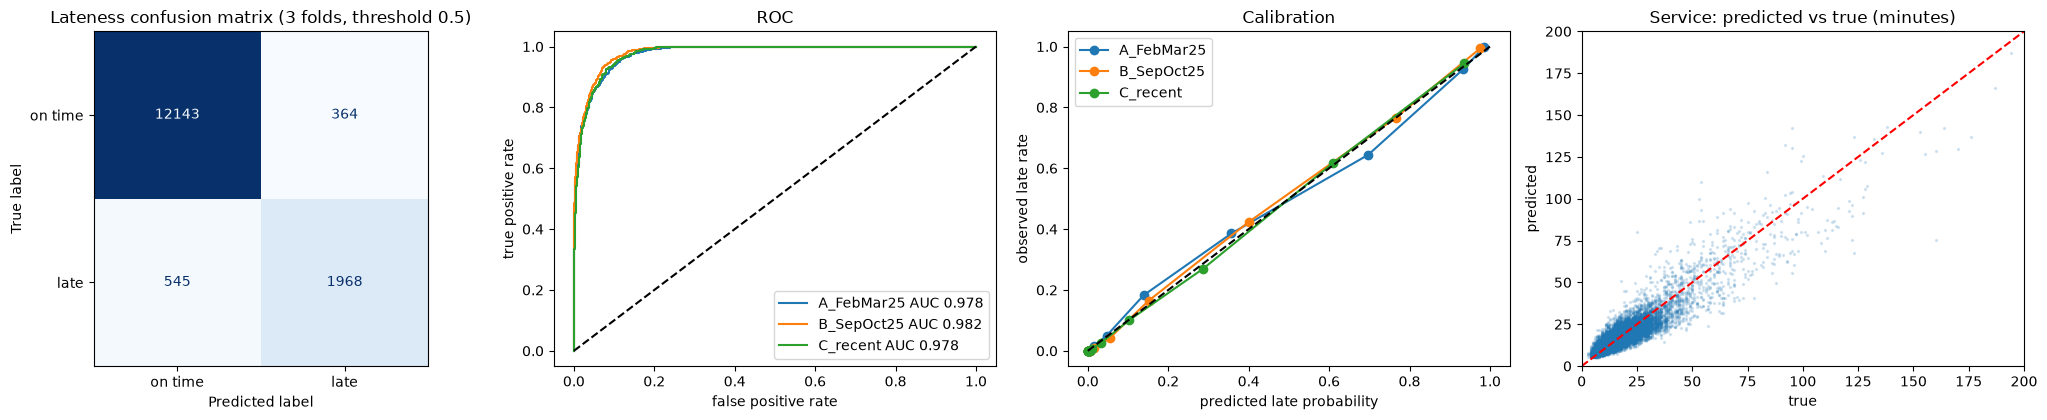

service MAE by brand: {'Fresh': 3.22, 'Style': 9.73, 'Tech': 12.43}


In [21]:
if RUN_CV:
    fig, ax = plt.subplots(1, 4, figsize=(21, 4.3))
    skm.ConfusionMatrixDisplay.from_predictions(cv.y_late, (cv.late_cal >= 0.5).astype(int), display_labels=['on time', 'late'],
                                                 cmap='Blues', values_format='d', ax=ax[0], colorbar=False)
    ax[0].set_title('Lateness confusion matrix (3 folds, threshold 0.5)')
    for f, g in cv.groupby('fold'):
        fpr, tpr, _ = skm.roc_curve(g.y_late, g.late_cal); ax[1].plot(fpr, tpr, label=f'{f} AUC {skm.roc_auc_score(g.y_late, g.late_cal):.3f}')
        b = pd.qcut(g.late_cal, 15, duplicates='drop'); c = g.groupby(b, observed=True)[['late_cal', 'y_late']].mean()
        ax[2].plot(c.late_cal, c.y_late, marker='o', label=f)
    ax[1].plot([0, 1], [0, 1], 'k--'); ax[1].set(title='ROC', xlabel='false positive rate', ylabel='true positive rate'); ax[1].legend()
    ax[2].plot([0, 1], [0, 1], 'k--'); ax[2].set(title='Calibration', xlabel='predicted late probability', ylabel='observed late rate'); ax[2].legend()
    ax[3].scatter(cv.y_svc, cv.svc_cal, s=2, alpha=.15); ax[3].plot([0, 200], [0, 200], 'r--'); ax[3].set(xlim=(0, 200), ylim=(0, 200),
                  title='Service: predicted vs true (minutes)', xlabel='true', ylabel='predicted')
    plt.tight_layout(); plt.show()
    print('service MAE by brand:', cv.assign(e=(cv.svc_cal - cv.y_svc).abs()).groupby('brand').e.mean().round(2).to_dict())

## 8. Final training on all data
The pipeline is refitted on every training delivery (2024-01-01 .. 2026-02-14). The calibration from section 7 is attached and the model is saved as a
dict of plain scikit-learn estimators (`models/task1_models.joblib`), loadable with `joblib` alone.

In [22]:
MODEL_PATH = MODEL_DIR / 'task1_models.joblib'
if RETRAIN:
    t0 = time.time()
    final_models = fit(train_X, arrival_for(train_X), FEATURES, t['traffic'])
    if RUN_CV:
        final_models['calibration'] = CALIBRATION
    elif MODEL_PATH.exists():
        final_models['calibration'] = joblib.load(MODEL_PATH).get('calibration')
    joblib.dump(final_models, MODEL_PATH, compress=3)
    print(f'trained and saved in {time.time() - t0:.0f}s ->', MODEL_PATH)
else:
    final_models = joblib.load(MODEL_PATH); print('loaded', MODEL_PATH)
assert final_models['features'] == FEATURES

stage 1: service OOF


stage 3: arrival-residual OOF


stage 4: lateness classifier x5


final service: raw x3, log x3, segment


trained and saved in 143s -> models\task1_models.joblib


## 9. Test predictions and submission
Keep the template's `delivery_id` values and row order; fill only the two prediction columns.

In [23]:
svc, late = predict(final_models, test_X, t['traffic'])
pred = pd.DataFrame({'delivery_id': test_X.delivery_id.values, 'pred_service_min': svc, 'pred_late_prob': late})
sub = t['template'][['delivery_id']].merge(pred, on='delivery_id', how='left', validate='one_to_one')
sub['pred_service_min'] = sub.pred_service_min.round(2)
sub['pred_late_prob'] = sub.pred_late_prob.clip(0, 1).round(4)
validate_submission(sub, t['template'])
sub.to_csv(PRED_DIR / 'submission_task1.csv', index=False)
validate_submission(pd.read_csv(PRED_DIR / 'submission_task1.csv'), t['template'])
print('saved and re-validated:', PRED_DIR / 'submission_task1.csv', sub.shape)
chk = test_X[['delivery_id', 'brand', 'monsoon']].assign(brand=lambda d: d.brand.astype(str)).merge(sub, on='delivery_id')
print('mean predicted late probability:', round(chk.pred_late_prob.mean(), 4), '| by monsoon:', chk.groupby('monsoon').pred_late_prob.mean().round(4).to_dict())
print(chk.groupby('brand')[['pred_service_min', 'pred_late_prob']].mean().round(3))
sub.head()

saved and re-validated: predictions\submission_task1.csv (5014, 3)
mean predicted late probability: 0.2222 | by monsoon: {0: 0.1422, 1: 0.2625}
       pred_service_min  pred_late_prob
brand                                  
Fresh            16.888           0.231
Style            49.979           0.059
Tech             61.832           0.021


,delivery_id,pred_service_min,pred_late_prob
0,ORD0092308,8.03,0.0009
1,ORD0092309,7.63,0.0015
2,ORD0092310,12.06,0.0010
3,ORD0092311,11.26,0.0073
4,ORD0092312,13.78,0.0063


## 10. Inference demo - load the saved models and predict
Loads `models/task1_models.joblib` from disk (fresh object), takes five test deliveries, and prints their raw inputs, the key engineered
features the model sees, and the predictions.

In [24]:
loaded = joblib.load(MODEL_DIR / 'task1_models.joblib')
print('loaded models:', {k: (f'{len(v)} x {type(v[0]).__name__}' if isinstance(v, list) and k not in ('features', 'f2', 'f3', 'segment_brands') else type(v).__name__)
                         for k, v in loaded.items() if k not in ('features', 'f2', 'f3', 'segment_brands')})
demo_ids = ['ORD0092308', 'ORD0092309'] + test_X.loc[test_X.brand.astype(str).isin(['Style', 'Tech']), 'delivery_id'].head(2).tolist() \
           + test_X.loc[test_X.sim_hist_slack < 20, 'delivery_id'].head(1).tolist()
demo_X = test_X[test_X.delivery_id.isin(demo_ids)]
d_svc, d_late = predict(loaded, demo_X, t['traffic'])

print('\nRAW INPUTS (task1_test_inputs.csv):')
print(t['orders_test'].set_index('delivery_id').loc[demo_X.delivery_id, ['order_date', 'outlet_id', 'brand', 'district', 'temp_requirement', 'order_units',
      'order_weight_kg', 'order_volume_m3', 'route_id', 'seq_in_route', 'vehicle_id', 'planned_arrival_time', 'window_open_time', 'window_close_time']].to_string())
print('\nKEY ENGINEERED FEATURES:')
print(demo_X.set_index('delivery_id')[['dock_type', 'service_allowance_min', 'exp_service_hist', 'disruption_index', 'plan_slack', 'sim_hist_slack', 'n_stops']].round(2).to_string())
print('\nPREDICTIONS:')
print(pd.DataFrame({'delivery_id': demo_X.delivery_id.values, 'pred_service_min': d_svc.round(2), 'pred_late_prob': d_late.round(4)}).to_string(index=False))

loaded models: {'svc_stage1': 'HistGradientBoostingRegressor', 'resid': 'HistGradientBoostingRegressor', 'late': '5 x HistGradientBoostingClassifier', 'svc_raw': '3 x HistGradientBoostingRegressor', 'svc_log': '3 x HistGradientBoostingRegressor', 'svc_segment': 'HistGradientBoostingRegressor', 'calibration': 'dict'}



RAW INPUTS (task1_test_inputs.csv):
             order_date outlet_id  brand district temp_requirement  order_units  order_weight_kg  order_volume_m3 route_id  seq_in_route vehicle_id planned_arrival_time window_open_time window_close_time
delivery_id                                                                                                                                                                                                
ORD0092429   2026-02-16    OUT110  Fresh  Badulla          chilled           32            188.9            1.064  R025216             0     VEH041                06:54            03:00             08:00
ORD0092308   2026-02-16    OUT001  Fresh  Colombo          ambient           11             92.1            0.501  R025229             0     VEH037                05:21            05:00             07:30
ORD0092309   2026-02-16    OUT002  Fresh  Colombo          ambient           12             96.2            0.539  R025229             2     VEH037

---
## Task 2A
*To be added.*